Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

plt.rcParams["figure.constrained_layout.use"] = True

# ROC-AUC curve visualisation

In [2]:
results = {
    "model": [],
    "variable": [],
    "cles": [],
    "ci_low": [],
    "ci_high": [],
    "U_val": [],
    "p_val": [],
    "n": [],
}

SEED = 42
N_BOOT = 5_000


def cles(extero, intero):
    """Common-language effect size: P(extero > intero), ties counted as one half.

    Computed from all pairwise comparisons, so it is the rank-based quantity
    equal to the area under the ROC curve.
    """
    return pg.compute_effsize(extero, intero, eftype="cles")


def add_result(model, variable, extero, intero):
    """CLES for one predictor, with a bootstrap CI and a Mann-Whitney test."""
    e = np.asarray(extero, dtype=float)
    i = np.asarray(intero, dtype=float)
    keep = np.isfinite(e) & np.isfinite(i)
    e, i = e[keep], i[keep]

    value = cles(e, i)
    ci = pg.compute_bootci(
        e,
        i,
        func=cles,
        n_boot=N_BOOT,
        confidence=0.95,
        seed=SEED,
        paired=True,  # resample participants, carrying both estimates together
        decimals=4,
    )

    # Fold above 0.5 so the score reads as discriminability whichever modality is
    # larger, applying the same flip to the interval.
    if value < 0.5:
        value, ci = 1.0 - value, [1.0 - ci[1], 1.0 - ci[0]]

    mwu = pg.mwu(e, i)  # independent-samples test

    results["model"].append(model)
    results["variable"].append(variable)
    results["cles"].append(value)
    results["ci_low"].append(ci[0])
    results["ci_high"].append(ci[1])
    results["U_val"].append(float(mwu["U_val"].iloc[0]))
    results["p_val"].append(float(mwu["p_val"].iloc[0]))
    results["n"].append(int(e.size))

In [3]:
standard_model_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "standard_model_summary.csv"
)
standard_model_df = standard_model_df[standard_model_df.session == 2]

add_result(
    "Dynamic beliefs",
    "Threshold",
    standard_model_df["extero_threshold"],
    standard_model_df["intero_threshold"],
)
add_result(
    "Dynamic beliefs",
    "Slope",
    standard_model_df["extero_slope"],
    standard_model_df["intero_slope"],
)

In [4]:
standard_model_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "standard_model_summary.csv"
)
standard_model_hgf_df.participant_id.nunique()

549

In [5]:
cardiac_believing_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_believing_summary.csv"
)
cardiac_believing_df = cardiac_believing_df[cardiac_believing_df.session == 2]

add_result(
    "Static beliefs",
    "Slope",
    cardiac_believing_df["extero_slope"],
    cardiac_believing_df["intero_std"],
)

In [6]:
weighted_update_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
weighted_update_df = weighted_update_df[weighted_update_df.session == 2]

add_result(
    "Weighted update",
    "Sensitivity",
    weighted_update_df["logit_exteroceptive_sensitivity"],
    weighted_update_df["logit_interoceptive_sensitivity"],
)
add_result(
    "Weighted update",
    "Belief precision",
    weighted_update_df["pi_extero_belief"],
    weighted_update_df["pi_cardiac_belief"],
)

In [7]:
cardiac_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
cardiac_hgf_df = cardiac_hgf_df[cardiac_hgf_df.session == 2]

add_result(
    "Cardiac HGF",
    "Sensitivity",
    cardiac_hgf_df["logit_exteroceptive_sensitivity"],
    cardiac_hgf_df["logit_interoceptive_sensitivity"],
)
add_result(
    "Cardiac HGF",
    "Belief precision",
    cardiac_hgf_df["exteroceptive_precision"],
    cardiac_hgf_df["interoceptive_precision"],
)

In [8]:
auc_df = pd.DataFrame(results)

# Single machine-readable source for every value the manuscript reports.
auc_df.to_csv(
    Path.cwd().parent.parent / "results" / "reported_statistics_roc_auc.csv",
    index=False,
)

auc_df.round(4)

,model,variable,cles,ci_low,ci_high,U_val,p_val,n
0,Dynamic beliefs,Threshold,0.7954,0.7665,0.8228,213420.0,0.0,518
1,Dynamic beliefs,Slope,0.7265,0.6952,0.7578,73375.0,0.0,518
2,Static beliefs,Slope,0.6242,0.5903,0.6585,100826.0,0.0,518
3,Weighted update,Sensitivity,0.8172,0.7903,0.8419,219268.0,0.0,518
4,Weighted update,Belief precision,0.9389,0.9247,0.9510,16382.0,0.0,518
5,Cardiac HGF,Sensitivity,0.9910,0.9828,0.9956,265908.0,0.0,518
6,Cardiac HGF,Belief precision,0.5948,0.5544,0.6353,108715.0,0.0,518


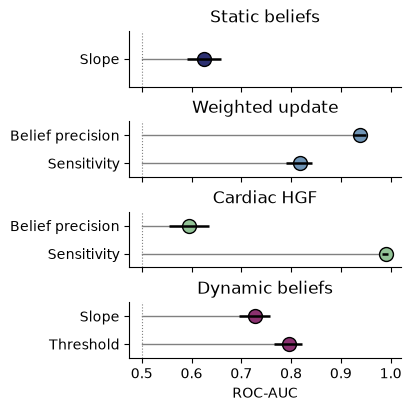

In [9]:
_, axs = plt.subplots(figsize=(4, 4), nrows=4, sharex=True)

for ax, model, color in zip(
    axs,
    ["Static beliefs", "Weighted update", "Cardiac HGF", "Dynamic beliefs"],
    ["#2c3071", "#6f94b5", "#92c396", "#8b3170"],
):
    sub = auc_df[auc_df.model == model].reset_index(drop=True)
    for ii, row in sub.iterrows():
        ax.plot([0.5, row.cles], [ii, ii], color="grey", linewidth=1.0, zorder=1)
        ax.scatter(y=ii, x=row.cles, color=color, edgecolor="k", s=100, zorder=2)
        # 95% bootstrap interval, drawn last so it reads on top of the marker.
        ax.plot(
            [row.ci_low, row.ci_high],
            [ii, ii],
            color="k",
            linewidth=1.8,
            solid_capstyle="butt",
            zorder=3,
        )
    ax.axvline(0.5, color="grey", linestyle=":", linewidth=0.8, zorder=0)
    ax.set(title=model, ylim=(-0.5, len(sub) - 0.5))
    ax.set_yticks(range(len(sub)), list(sub.variable))

axs[3].set(xlabel="ROC-AUC")
sns.despine()

plt.savefig(
    Path().cwd().parent.parent / "figures" / "figure_5_ROC_AUC.svg", bbox_inches="tight"
)

In [10]:
for _, r in auc_df.iterrows():
    print(
        "%-16s %-18s CLES = %.3f [%.3f, %.3f]  U = %.0f  p = %.3g  n = %d"
        % (
            r.model,
            r.variable,
            r.cles,
            r.ci_low,
            r.ci_high,
            r.U_val,
            r.p_val,
            r.n,
        )
    )

Dynamic beliefs  Threshold          CLES = 0.795 [0.766, 0.823]  U = 213420  p = 7.19e-61  n = 518
Dynamic beliefs  Slope              CLES = 0.727 [0.695, 0.758]  U = 73375  p = 1.57e-36  n = 518
Static beliefs   Slope              CLES = 0.624 [0.590, 0.658]  U = 100826  p = 4.43e-12  n = 518
Weighted update  Sensitivity        CLES = 0.817 [0.790, 0.842]  U = 219268  p = 6.68e-70  n = 518
Weighted update  Belief precision   CLES = 0.939 [0.925, 0.951]  U = 16382  p = 4.02e-132  n = 518
Cardiac HGF      Sensitivity        CLES = 0.991 [0.983, 0.996]  U = 265908  p = 8.34e-165  n = 518
Cardiac HGF      Belief precision   CLES = 0.595 [0.554, 0.635]  U = 108715  p = 1.26e-07  n = 518
